# Phase 3: Vetting model

Most dips that look like planets aren't. Common impostors are **eclipsing binaries** (two stars orbiting each other),
**background eclipsing binaries** (a binary blended into the target's light), and **instrument glitches**.

The Kepler mission vetted thousands of signals by hand and with its Robovetter. The KOI table in the NASA Exoplanet Archive
records the verdicts: `CONFIRMED` planets and `FALSE POSITIVE`s. We train a random forest on those labels to score how
planet-like a new signal is.

**Feature rule:** we only use what our own BLS search can also measure: the signal's period, duration, depth, and implied size,
plus the star's temperature, radius, and surface gravity. We leave out signal-to-noise and transit count on purpose. Kepler
had four years of data and a search here might have four months, so those numbers would mean different things.

The feature code lives in `backend/app/vetting.py`. The API uses the exact same code to score signals.

In [1]:
import json, sys, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.inspection import permutation_importance
import joblib

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "backend"))
from app.vetting import FEATURES, FEATURE_LABELS, features_from_koi, MODEL_PATH, META_PATH

CACHE = ROOT / "data" / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

## 1. Download the KOI table

About 9,500 signals. The download is cached in `data/cache/`, which is git-ignored.

In [2]:
koi_csv = CACHE / "koi_cumulative.csv"
if not koi_csv.exists():
    cols = "kepid,kepoi_name,kepler_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_prad,koi_steff,koi_srad,koi_slogg"
    url = ("https://exoplanetarchive.ipac.caltech.edu/TAP/sync?format=csv&query="
           + f"select+{cols}+from+cumulative")
    pd.read_csv(url).to_csv(koi_csv, index=False)

koi = pd.read_csv(koi_csv)
koi["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2748
CANDIDATE         1977
Name: count, dtype: int64

## 2. Labels and features

`CONFIRMED` = 1, `FALSE POSITIVE` = 0. `CANDIDATE`s are unresolved, so we hold them out and score them at the end.

In [3]:
labeled = koi[koi["koi_disposition"].isin(["CONFIRMED", "FALSE POSITIVE"])].reset_index(drop=True)
X = pd.DataFrame([features_from_koi(r) for _, r in labeled.iterrows()])[FEATURES]
y = (labeled["koi_disposition"] == "CONFIRMED").astype(int).values
groups = labeled["kepid"].values  # several signals can share a star

print(f"{len(X)} labeled signals: {y.sum()} planets, {(1 - y).sum()} false positives")
print(f"Accuracy of always guessing 'false positive': {1 - y.mean():.1%}")
X.describe().T[["mean", "50%", "min", "max", "count"]]

7587 labeled signals: 2748 planets, 4839 false positives
Accuracy of always guessing 'false positive': 63.8%


,mean,50%,min,max,count
period_days,51.655165,8.088017,0.241843,1.071233e+03,7587.0
duration_hours,5.712962,3.836610,0.104600,1.385400e+02,7587.0
depth_ppm,29521.859634,501.500000,0.800000,1.541400e+06,7328.0
planet_radius_earth,104.143442,2.620000,0.080000,2.003460e+05,7328.0
star_teff,5716.201283,5774.500000,2661.000000,1.589600e+04,7328.0
star_radius_sun,1.752932,1.000000,0.116000,2.299080e+02,7328.0
star_logg,4.310672,4.438000,0.047000,5.283000e+00,7328.0
duration_ratio,1.250576,0.964805,0.003311,2.738316e+01,7328.0


## 3. Cross-validation

We use five folds, **grouped by star**. Every signal from a star lands in the same fold, so the model can't score a star
it already saw during training. That would inflate the scores.

In [4]:
def make_model():
    return RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5, max_depth=14,
        class_weight="balanced", n_jobs=-1, random_state=42,
    )

oof = np.zeros(len(y))
importances = []
for fold, (tr, te) in enumerate(GroupKFold(n_splits=5).split(X, y, groups)):
    m = make_model().fit(X.iloc[tr], y[tr])
    oof[te] = m.predict_proba(X.iloc[te])[:, 1]
    if fold == 0:
        pi = permutation_importance(m, X.iloc[te], y[te], scoring="roc_auc", n_repeats=5, random_state=0)
        importances = pi.importances_mean

pred = (oof >= 0.5).astype(int)
metrics = {
    "roc_auc": round(roc_auc_score(y, oof), 4),
    "accuracy": round(accuracy_score(y, pred), 4),
    "precision": round(precision_score(y, pred), 4),
    "recall": round(recall_score(y, pred), 4),
    "baseline_accuracy": round(1 - y.mean(), 4),
}
print(json.dumps(metrics, indent=2))
tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
print(f"Planets kept: {tp} / {tp + fn}   False positives wrongly passed: {fp} / {fp + tn}")

{
  "roc_auc": 0.9633,
  "accuracy": 0.9006,
  "precision": 0.8248,
  "recall": 0.9214,
  "baseline_accuracy": 0.6378
}
Planets kept: 2532 / 2748   False positives wrongly passed: 538 / 4839


## 4. What the model relies on

Permutation importance measures how much the score drops when one feature is shuffled.

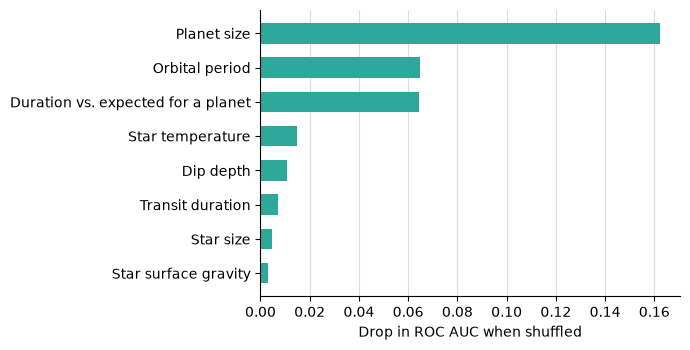

In [5]:
order = np.argsort(importances)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh([FEATURE_LABELS[FEATURES[i]] for i in order], importances[order], color="#2fa89c", height=0.6)
ax.set_xlabel("Drop in ROC AUC when shuffled")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#ddd", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()

**Planet size** is the strongest clue: anything that would be bigger than about 2 Jupiters (≈ 22 × Earth) is almost
certainly a star. **Orbital period** and the **duration ratio** come next. The duration ratio compares a signal's actual
duration with the duration expected for a planet orbiting this star, and eclipsing binaries and blended background stars
often break that relationship.

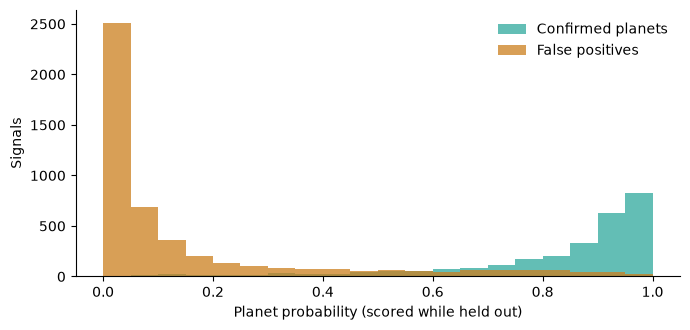

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
bins = np.linspace(0, 1, 21)
ax.hist(oof[y == 1], bins=bins, alpha=0.75, label="Confirmed planets", color="#2fa89c")
ax.hist(oof[y == 0], bins=bins, alpha=0.75, label="False positives", color="#cc7f1e")
ax.set_xlabel("Planet probability (scored while held out)")
ax.set_ylabel("Signals")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## 5. Train the final model on all labeled signals and save it

In [7]:
model = make_model().fit(X, y)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH, compress=3)
meta = {
    "model": "RandomForestClassifier",
    "features": FEATURES,
    "trained_on": "Kepler KOI cumulative table (NASA Exoplanet Archive), CONFIRMED vs FALSE POSITIVE",
    "n_train": int(len(y)),
    "n_planets": int(y.sum()),
    "n_false_positives": int((1 - y).sum()),
    "cv": "5-fold GroupKFold by star (kepid)",
    "metrics": metrics,
    "feature_importance": {FEATURES[i]: round(float(importances[i]), 4) for i in range(len(FEATURES))},
    "sklearn_version": sklearn.__version__,
    "trained": datetime.date.today().isoformat(),
}
META_PATH.write_text(json.dumps(meta, indent=2))
print(f"Saved {MODEL_PATH.name} ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

Saved vetting_rf.joblib (2.0 MB)


## 6. Sanity check: score the unresolved candidates

This isn't a test, since there are no labels. It shows how the model would sort the signals Kepler never resolved. A split near 50/50 means this pool is a real mix, and the model isn't just rubber-stamping everything as a planet.

In [8]:
cand = koi[koi["koi_disposition"] == "CANDIDATE"]
Xc = pd.DataFrame([features_from_koi(r) for _, r in cand.iterrows()])[FEATURES]
pc = model.predict_proba(Xc)[:, 1]
print(f"{len(pc)} candidates, median planet probability {np.median(pc):.2f}; "
      f"{(pc >= 0.7).mean():.0%} score as likely planets, {(pc <= 0.3).mean():.0%} as likely false positives")

1977 candidates, median planet probability 0.52; 36% score as likely planets, 36% as likely false positives
